In [19]:

from dataclasses import asdict

from src.agents.nodes.sql_generate_query_node import generate_sql_node
from utils.sql_tools import WmsSqlTool
from langchain_community.tools.sql_database.tool import QuerySQLDatabaseTool, QuerySQLCheckerTool, InfoSQLDatabaseTool,ListSQLDatabaseTool
from langchain_google_genai import ChatGoogleGenerativeAI
from src.config import settings

_llm = None

def _getllm() -> ChatGoogleGenerativeAI:
    global _llm

    if _llm is None:
        _llm = ChatGoogleGenerativeAI(
            model=settings.GOOGLE_AI_MODEL,
            api_key=settings.GOOGLE_API_KEY,


        )
    return _llm
tools = WmsSqlTool(query_check_llm=_getllm())

query_tool = next(t for t in tools.get_sql_tools() if isinstance(t, QuerySQLDatabaseTool))
query_check = next(t for t in tools.get_sql_tools() if isinstance(t, QuerySQLCheckerTool))
list_tables = next(t for t in tools.get_sql_tools() if isinstance(t, ListSQLDatabaseTool))
list_info = next(t for t in tools.get_sql_tools() if isinstance(t, InfoSQLDatabaseTool))

res= list_info.invoke({"table_names": list_tables.invoke("")})


ImportError: cannot import name 'generate_sql_node' from 'src.agents.nodes.sql_generate_query_node' (/Users/rahul/Library/Mobile Documents/com~apple~CloudDocs/SCM_Agentic_Ai/WMS_Incident_Copilot/src/agents/nodes/sql_generate_query_node.py)

In [ ]:
res

In [ ]:
tool = tools.get_sql_tools()

next(t for t in tool if isinstance(t, QuerySQLDatabaseTool))

In [ ]:
from pprint import pprint
check_sql = "select * from inventory wher limit 10"
checked_sql = query_check.invoke({"query": check_sql})
pprint(checked_sql)


In [ ]:
from data.state import WMState
from agents.nodes.query_enrich_node import router_node

state = WMState(
    ticket_number= "INC12345",
    description= "how to slot sku003 and how much",
    user_id= "rahul"
)

router = router_node(state)

router


In [ ]:
from agents.graph.sql_subgraph import sql_graph
from domain.states.sql_subgraph_state.sql_graph_state import SQLGraphState
from dotenv import load_dotenv
load_dotenv()
state = SQLGraphState(

    description= "how many picks left?",
    domain="outbound"
)

router = sql_graph.invoke(state)

from rich.console import Console
from rich.markdown import Markdown
console = Console()

console.print(Markdown(router['final_response']))


In [ ]:
from langgraph.graph import StateGraph, START, END
from src.data.state import WMState
from IPython.display import display, Image
from src.agents.nodes.query_enrich_node import router_node
from agents.graph.sql_subgraph import sql_graph
from src.agents.nodes.sql_result_node import return_result_node
from src.agents.edges.router_intent_edge import router_intent_edge
from langgraph.cache.memory import InMemoryCache
from agents.nodes.supervisor_node import SupervisorNode
from agents.nodes.inbound_agent_node import inbound_agent_node
from agents.nodes.outbound_agent_node import outbound_agent_node
from agents.nodes.inventory_agent_node import inventory_agent_node
from dotenv import load_dotenv
load_dotenv()
builder = StateGraph(WMState)
supervisor_node = (SupervisorNode())

builder.add_node("router_node", router_node)
builder.add_node("sql_query_subgraph", sql_graph)
builder.add_node("return_result_node", return_result_node)
builder.add_node("supervisor_node", supervisor_node)
builder.add_node("inbound_agent_node", inbound_agent_node)
builder.add_node("outbound_agent_node", outbound_agent_node)
builder.add_node("inventory_agent_node", inventory_agent_node)


builder.add_edge(START, "router_node")
builder.add_conditional_edges(
    "router_node",
    router_intent_edge,
    {
        "lookup":"sql_query_subgraph",
        "diagnose": "supervisor_node"
    }
)
builder.add_conditional_edges(
    "supervisor_node",
    lambda state: ["inbound_agent_node", "outbound_agent_node", "inventory_agent_node"],
    {
        "inbound_agent_node": "inbound_agent_node",
        "outbound_agent_node": "outbound_agent_node",
        "inventory_agent_node": "inventory_agent_node",
    }
)

# Agents → back to supervisor
builder.add_edge("inbound_agent_node", "supervisor_node")
builder.add_edge("outbound_agent_node", "supervisor_node")
builder.add_edge("inventory_agent_node", "supervisor_node")

# Supervisor can also go to result
builder.add_edge("return_result_node", END)

graph = builder.compile(cache=InMemoryCache())

display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
result = await graph.ainvoke(
    {
        "ticket_number": "INC12345",
        "description": "what all issues in inbound ?",
        "user_id": "rahul",
        "domain": "inventory",
    }
)

from rich.console import Console
from rich.markdown import Markdown

console = Console()

print(type(result))
print(result)

final_text = result.get("final_response") or str(result)
print("FINAL_TEXT:", repr(final_text))

console.print(Markdown(final_text))

In [ ]:


from langchain_core.messages import HumanMessage

from data.state import WMState
from models.model_loader import get_google_llm

get_google_llm().invoke([HumanMessage(content="Hello")]).content[0]["text"].strip()

In [20]:


from agents.nodes.supervisor_node import SupervisorNode
from data.state import WMState

message = (
   "picking is low and uph is low but invenotry is high why and also inbound has no work"
)

state = WMState(
    ticket_number="INC12345",
    description=message,
    user_id="rahul",
)


node = SupervisorNode()
response = await node(state)
print(response)


ImportError: cannot import name 'SupervisorNode' from 'agents.nodes.supervisor_node' (/Users/rahul/Library/Mobile Documents/com~apple~CloudDocs/SCM_Agentic_Ai/WMS_Incident_Copilot/src/agents/nodes/supervisor_node.py)

In [ ]:
for data in response.goto:
    print(data)
    print("="*90)


In [ ]:
from agents.nodes.supervisor_node import SupervisorNode
from agents.nodes.inbound_agent_node import inbound_agent_node
from data.state import WMState, WorkerInput

AGENTS = {
    "inbound_agent": inbound_agent_node,
    # "outbound_agent": outbound_agent_node,
    # "inventory_agent": inventory_agent_node,
}

message = (
    "whats the over wms load"
)

state = WMState(
    ticket_number="INC12345",
    description=message,
    user_id="rahul",
)

supervisor = SupervisorNode()

# Run supervisor
cmd = await supervisor(state)
print("Supervisor returned:")
print(cmd)


In [ ]:
from agents.graph.sql_subgraph import sql_graph
from data.state import SQLGraphState
state2 = SQLGraphState(
    domain="outbound",
    description="how much left in picking outbound and what all skus"
)

res = sql_graph.invoke(state2)

res

In [ ]:
state2 = SQLGraphState(
    domain="outbound",
    description="how much sku do we need for picking"
)

res = sql_graph.invoke(state2)

res

In [ ]:
from models.model_loader import get_openai_fast_llm
from domain.states.supervisor.supervisor_subagent_task_state import SupervisorToSubAgentDeligationItem

llm = get_openai_fast_llm().with_structured_output(SupervisorToSubAgentDeligationItem)

response = llm.invoke([
    {"role": "system", "content": "You are a WMS diagnose agent elaborate issues in depth"},
    {"role": "user", "content": "whats my inbound issues"}
])

response

In [ ]:
for data in response.subagent_deligations:
    print(data.subagent_task)
    print("="*19)

In [ ]:
from agents.nodes.supervisor_node import SupervisorNode
from domain.states.supervisor.diagnose_graph_state import WMState

message = (
    "whats inbound staus"
)
state = WMState(
    ticket_number="INC12345",
    description=message,
)


node = SupervisorNode()
response = await node(state)
print(response)


# subagent_name= subagent_name,
#             worker_task=subagent_research_task,
#             task_id=str(task_id),
#             domain_name=domain,

In [ ]:
response.goto

In [ ]:
from langgraph.graph import StateGraph, START, END
from domain.states.supervisor.diagnose_graph_state import WMState
from IPython.display import display, Image
from src.agents.nodes.query_enrich_node import router_node
from agents.graph.sql_subgraph import sql_graph
from agents.edges.router_intent_edge import router_intent_edge
from agents.nodes.supervisor_node import WarehouseSupervisorNode
from agents.nodes.diagnose_result_node import diagnose_result_node
from agents.nodes.sql_lookup_subgraph_node import sql_query_subgraph_node
from dotenv import load_dotenv
load_dotenv()
builder = StateGraph(WMState)
supervisor_node = WarehouseSupervisorNode()

builder.add_node("router_node", router_node)
builder.add_node("sql_query_subgraph_node", sql_query_subgraph_node)

builder.add_node("supervisor_node", supervisor_node)
builder.add_node("diagnose_result_node", diagnose_result_node)

builder.add_edge(START, "router_node")

builder.add_conditional_edges(
    "router_node",
    router_intent_edge,
    {
        "lookup": "sql_query_subgraph_node",
        "diagnose": "supervisor_node",
    },
)

# lookup path ends here
builder.add_edge("sql_query_subgraph_node", END)

# diagnose_result_node is your explicit finish node
builder.add_edge("diagnose_result_node", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:

result = await graph.ainvoke(
    {
        "ticket_number":"INC12345",
        "description":"what status of inbound ?",
    }
)

from rich.console import Console
from rich.markdown import Markdown

console = Console()

print(type(result))
print(result)

final_text = result.get("final_responses") or str(result)

console.print(Markdown(final_text['final_responses']))

In [ ]:
final_text['final_responses']

In [ ]:
from agents.nodes.query_enrich_node import router_node
from domain.states.supervisor.diagnose_graph_state import WMState

state = WMState(
    ticket_number="INC12345",
    description="what is the sttus of sku 003",
    session_id="rahul"
)

res = router_node(state)

print(res)

In [21]:
from langgraph.graph import StateGraph
from domain.states.sql_subgraph_state.sql_graph_state import SQLGraphState
from IPython.display import display, Image
from domain.states.sql_subgraph_state.sql_graph_state import SQLGraphState
from src.agents.nodes.sql_load_skills_node import sql_load_skills_node
from src.agents.nodes.sql_generate_query_node import sql_generate_query_node
from src.agents.nodes.check_sql_node import check_sql_node
from src.agents.nodes.sql_run_sql_node import sql_run_sql_node
from src.agents.nodes.sql_result_node import sql_result_node
from langgraph.graph import StateGraph, START, END

sql_graph_state = StateGraph(SQLGraphState)
builder = sql_graph_state.add_sequence([
        sql_load_skills_node,
        sql_generate_query_node,
        check_sql_node,
        sql_run_sql_node,
        sql_result_node,
    ])

sql_graph_state.add_edge(START, "sql_load_skills_node")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


ModuleNotFoundError: No module named 'src.agents.nodes.sql_result_node'

In [ ]:
example = SQLGraphState(
    domain="outbound",
    user_question="whats the total picks left?",
)

result = graph.invoke(example)

import pandas as pd

df = pd.DataFrame(result.get('result').rows)
df

In [ ]:
result.get('result').rows

In [ ]:
from runtime.session_runtime import WMSSessionRuntime
from agents.graph.application_graph import graph
runtime = WMSSessionRuntime(graph)

# First run
result = await runtime.run(
    session_id="prajwal",
    ticket_number="INC123454343",
    description="how much sku 004 i have?"
)

# Second run — same session, history saved
# result = await runtime.run(
#     session_id="rahul",
#     user_input="now check outbound picking"
# )
print(result)

In [ ]:
resultt = await runtime.run(
    session_id="prajwal",
    ticket_number="INC123454343",
    description="how much sku 004 i have?"
)
result


In [ ]:
from agents.graph.application_graph import graph

graph = graph

res = graph.invoke({
     "ticket_number":"INC12345",
    "session_id":"manju",
    "user_id":"manju",
    "description":"can i get steps for putaway from inbound",
}, config={"configurable": {"thread_id":"manju"}})

In [ ]:
from rich.markdown import Markdown
from rich.console import  Console

console = Console()

console.print(Markdown(''.join(res.get("diagnosis_result").citations)))


In [ ]:
config={"configurable": {"thread_id":"manju"}}
history = list(graph.get_state_history(config))

for i, s in enumerate(history):
    print(f"\n--- checkpoint {i} ---")
    print("config:", s.config)
    print("next:", s.next)
    print("values:", s.values)  # includes checkpoint info

In [ ]:
history = list(graph.get_state_history(config))
old_snapshot = history[7]   # example: choose one checkpoint

replay_result = graph.invoke(None, old_snapshot.config)
print(replay_result)

In [ ]:
from agents.nodes.supervisor_node import WarehouseSupervisorNode
from domain.states.supervisor.diagnose_graph_state import WMState

WarehouseSupervisorNode().__call__(WMState(
        description="whats the methos to palletize inboudn inventory ",
        ticket_number="INC2003",
        user_id="rahul",
        session_id="Rahul"

    ))

In [ ]:
from functools import lru_cache
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from domain.states.supervisor.diagnose_graph_state import WMState
from agents.nodes.supervisor_node import WarehouseSupervisorNode
from agents.nodes.verification_node import verification_node
from agents.nodes.query_enrich_node import query_enrich_node
from agents.nodes.result_node import result_node
from agents.edges.verification_router import route_after_verification
from IPython.display import display, Image

supervisor_node = WarehouseSupervisorNode()

@lru_cache(maxsize=1)
def _application_graph():
    builder = StateGraph(WMState)

    builder.add_node("query_enrich_node", query_enrich_node)
    builder.add_node("supervisor_node", supervisor_node)
    builder.add_node("verification_node", verification_node)
    builder.add_node("result_node", result_node)

    builder.add_edge(START, "query_enrich_node")
    builder.add_edge("query_enrich_node", "supervisor_node")
    builder.add_edge("supervisor_node", "verification_node")

    builder.add_conditional_edges(
        "verification_node",
        route_after_verification,
        {
            "supervisor": "supervisor_node",
            "result": "result_node",
        },
    )
    # builder.add_edge("supervisor_node", "result_node")
    builder.add_edge("result_node", END)
    return builder

_application_graph.cache_clear()
checkpointer = InMemorySaver()
graph = _application_graph().compile(checkpointer=checkpointer)

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
from domain.states.supervisor.diagnose_graph_state import WMState

data = graph.invoke(
    WMState(
        description="how to putaway inbound inventory?",
        session_id="example",
        ticket_number="INC",
        user_id="rahul",
    ),
    config={
        "configurable": {
            "thread_id": "example"
        }
    }
)

print(data)

In [ ]:
from rich.markdown import Markdown
from rich.console import Console
console = Console()

data.get('evidence_records')

In [ ]:
from copy import deepcopy
from domain.states.supervisor.diagnose_graph_state import WMState
from agents.nodes.router_node import router_node
from agents.nodes.parallel_execution_node import plan_parallel_subtask_node
from dataclasses import asdict

state = WMState(
    description="how much work i have left in outbound, inbound?",
    ticket_number="INC2003",
    user_id="rahul",
    session_id="Rahul"
)

router = router_node(state=state)   # likely returns dict
print(router)
state2 = WMState(
    **{**asdict(state), **deepcopy(router)}
)

parallel = plan_parallel_subtask_node(state2)
print(parallel)

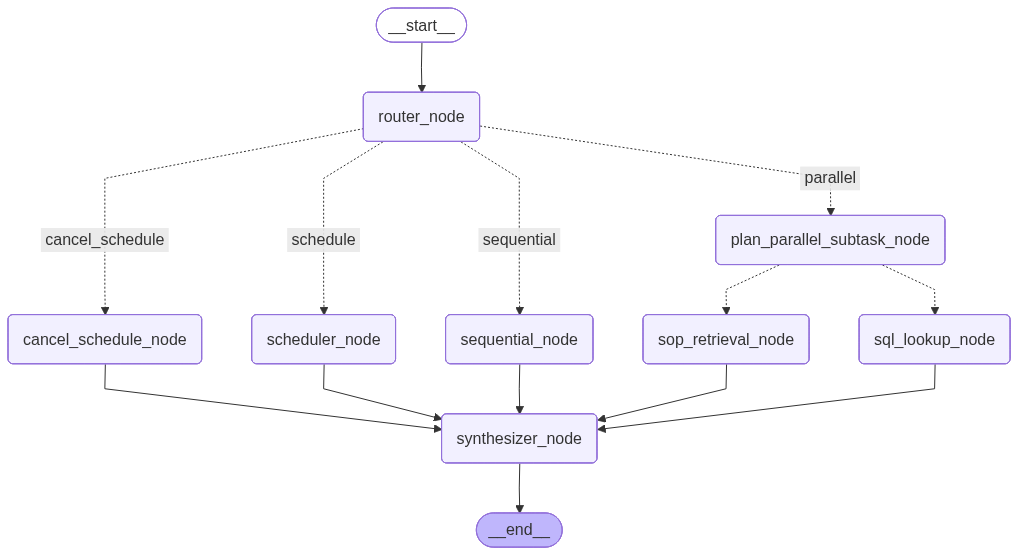

In [2]:
from functools import lru_cache
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import display, Image

from domain.states.supervisor.diagnose_graph_state import WMState
from agents.nodes.router_node import router_node
from agents.nodes.parallel_execution_node import plan_parallel_subtask_node
from agents.nodes.sql_lookup_node import sql_lookup_node
from agents.nodes.sop_lookup_node import sop_lookup_node
from agents.nodes.synthesizer_node import synthesizer_node
from agents.edges.fan_out_edge import fan_out_edge
from agents.edges.route_after_router import route_after_router
from agents.nodes.sequential_agent import sequential_agent
from agents.nodes.schedule_registrar_node import schedule_registrar_node
from agents.nodes.cancel_scheduler_node import cancel_scheduler_node

@lru_cache(maxsize=1)
def _application_graph():
    builder = StateGraph(WMState)

    # Nodes
    builder.add_node("router_node", router_node)
    builder.add_node("plan_parallel_subtask_node", plan_parallel_subtask_node)
    builder.add_node("sql_lookup_node", sql_lookup_node)
    builder.add_node("sop_retrieval_node", sop_lookup_node)
    builder.add_node("synthesizer_node", synthesizer_node)
    builder.add_node("sequential_node", sequential_agent)
    builder.add_node("scheduler_node", schedule_registrar_node)
    builder.add_node("cancel_schedule_node", cancel_scheduler_node)

    # Entry point
    builder.add_edge(START, "router_node")

    # Router decides: parallel (for now only path) — sequential path to be added later
    builder.add_conditional_edges(
        "router_node",
        route_after_router,
        {
            "parallel": "plan_parallel_subtask_node",
            "sequential": "sequential_node",
            "schedule": "scheduler_node",
            "cancel_schedule": "cancel_schedule_node",
            # "sequential": "react_agent_node",  # add when sequential path is built
        },
    )

    # Planner → fan-out to workers (parallel execution)
    builder.add_conditional_edges(
        "plan_parallel_subtask_node",
        fan_out_edge,
        ["sql_lookup_node", "sop_retrieval_node"],
    )

    # Workers → synthesizer (barrier: waits for ALL parallel workers)
    builder.add_edge("sql_lookup_node", "synthesizer_node")
    builder.add_edge("sop_retrieval_node", "synthesizer_node")
    builder.add_edge("sequential_node", "synthesizer_node")
    builder.add_edge("scheduler_node", "synthesizer_node")
    builder.add_edge("cancel_schedule_node", "synthesizer_node")

    # Synthesizer → END
    builder.add_edge("synthesizer_node", END)

    return builder


_application_graph.cache_clear()
checkpointer = InMemorySaver()
graph = _application_graph().compile(checkpointer=checkpointer)

display(Image(graph.get_graph().draw_mermaid_png()))

In [1]:
import uuid
from agents.graph.application_graph import graph
from domain.states.supervisor.diagnose_graph_state import WMState
data = await graph.ainvoke(
    WMState(
        ticket_number="INC0003",
        session_id="example",
        user_id="rahul",
        description="can you watch over sku009 and provide updates on picking progress? ",
    ),
    config={"configurable": {"thread_id": str(uuid.uuid4().hex[:5])}},
)

data['summarized_result']

2026-04-19 20:09:48,411 | INFO | apscheduler.scheduler | Scheduler started
2026-04-19 20:09:48,695 | INFO | agents.nodes.router_node | task='schedule' enriched='picking progress for SKU009' interval=None condition=None
2026-04-19 20:09:48,696 | INFO | agents.edges.route_after_router | Routing to SCHEDULE path (ticket=INC0003, query=picking progress for SKU009)
2026-04-19 20:09:48,699 | INFO | apscheduler.scheduler | Added job "schedule_task.<locals>.run" to job store "default"
2026-04-19 20:09:48,699 | INFO | infrastructure.monitoring_registry | Scheduled 83850be8b4a5 every 30s: 'picking progress for SKU009'


{'summarized_issue': 'A monitoring task for picking progress of SKU009 has been registered (ID: 83850be8b4a5) and is scheduled for continuous checking.',
 'confidence': 1.0,
 'citations': [{'source_type': 'other',
   'reference': "Registered (ID: 83850be8b4a5). Checking every 0 min: 'picking progress for SKU009'"}]}

In [2]:
from infrastructure.monitoring_registry import list_jobs

list_jobs()

[{'query': 'picking progress for SKU009',
  'interval_seconds': 30,
  'ticket_number': 'INC0003',
  'user_id': 'rahul',
  'original_session_id': 'example',
  'is_scheduled_run': False,
  'id': '83850be8b4a5',
  'status': 'active',
  'run_count': 0,
  'created_at': datetime.datetime(2026, 4, 19, 20, 9, 48, 698219, tzinfo=zoneinfo.ZoneInfo(key='America/Los_Angeles')),
  'last_run_at': None,
  'last_result': None}]

2026-04-19 20:10:18,705 | INFO | apscheduler.executors.default | Running job "schedule_task.<locals>.run (trigger: interval[0:00:30], next run at: 2026-04-19 20:10:48 PDT)" (scheduled at 2026-04-19 20:10:18.699005-07:00)
2026-04-19 20:10:18,721 | INFO | agents.nodes.router_node | task='parallel' enriched='Retrieve the picking progress for SKU009' interval=None condition=None
2026-04-19 20:10:18,724 | INFO | agents.edges.route_after_router | Routing to PARALLEL path (ticket=INC0003, query=Retrieve the picking progress for SKU009)
2026-04-19 20:10:18,769 | INFO | agents.nodes.sql_lookup_node | SQL Lookup Node: ['outbound']
2026-04-19 20:10:18,787 | INFO | agents.nodes.sql_generate_query_node | SQL Generate Query Node completed. Domains: ['outbound']
2026-04-19 20:10:22,837 | INFO | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-19 20:10:26,467 | INFO | agents.nodes.sql_run_sql_node | SQL node completed. Success: True, Domains: ['outbo

{'summarized_issue': 'Picking progress for SKU009 is currently at 46.14%, with 1,482 units picked out of a total requested 3,212 units.', 'confidence': 1.0, 'citations': [{'source_type': 'sql', 'reference': "SELECT\n    SUM(quantity) AS total_requested_quantity,\n    SUM(pck_qty) AS total_picked_quantity,\n    (SUM(pck_qty) * 100.0 / NULLIF(SUM(quantity), 0)) AS completion_percentage\nFROM wms1.pckwrk\nWHERE sku = 'SKU009'"}]}


In [3]:
import uuid
from agents.graph.application_graph import graph
from domain.states.supervisor.diagnose_graph_state import WMState
data = await graph.ainvoke(
    WMState(
        ticket_number="INC0003",
        session_id="example",
        user_id="rahul",
        description="cancel all jobs ",
    ),
    config={"configurable": {"thread_id": str(uuid.uuid4().hex[:5])}},
)

data['summarized_result']

2026-04-19 20:10:30,697 | INFO | agents.nodes.router_node | task='cancel_schedule' enriched='all active monitoring jobs' interval=None condition=None
2026-04-19 20:10:30,698 | INFO | agents.edges.route_after_router | Routing to CANCEL path (ticket=INC0003, query=all active monitoring jobs)
2026-04-19 20:10:30,699 | INFO | apscheduler.scheduler | Removed job 83850be8b4a5
2026-04-19 20:10:30,699 | INFO | agents.nodes.cancel_scheduler_node | FOUND JOBS, CANCELLING ['83850be8b4a5']


{'summarized_issue': 'No incident data provided for synthesis.',
 'confidence': 1.0,
 'citations': []}

In [4]:
list_jobs()

[]